In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/drive/MyDrive/DP_Midterm', exist_ok=True)

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from opacus import PrivacyEngine
import matplotlib.pyplot as plt
import pandas as pd

# Load MNIST Dataset

In [5]:
# Converts images from pixel values to floats
# And normalize the data using MNIST's known mean and std
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Load with batches of 256 images and randomized order to avoid overfitting
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.58MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.63MB/s]


# Define the Model

In [8]:
"""
Architecture follows the paper's setup:
  - Conv(16, 8x8, stride=2, padding=2) + ReLU + MaxPool(2x2)
  - Conv(32, 4x4, stride=2, padding=0) + ReLU + MaxPool(2x2)
  - Fully connected 32 -> 10 (output logits)
"""
class MnistCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        # Firt Layer
        nn.Conv2d(1, 16, 8, stride=2, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(2, 1),

        # Second Layer
        nn.Conv2d(16, 32, 4, stride=2, padding=0),
        nn.ReLU(),
        nn.MaxPool2d(2, 1),

        # Flatten to 1d
        nn.Flatten(),
        nn.Linear(32 * 4 * 4, 32),  # Fully connected layer
        nn.ReLU(),
        nn.Linear(32, 10) # Output 10 classes
    )

  def forward(self, x):
    return self.net(x)

# Train + Evaluate Functions

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_with_dp(noise_multiplier, epochs=10):
    model = MnistCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.25)
    criterion = nn.CrossEntropyLoss()

    private_train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    privacy_engine = PrivacyEngine()
    model, optimizer, private_train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=private_train_loader,
        noise_multiplier=noise_multiplier,
        max_grad_norm=1.0,
    )

    epsilons_per_epoch = []
    accuracies_per_epoch = []

    for epoch in range(epochs):
        model.train()
        for x, y in private_train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        # Record epsilon and accuracy after each epoch
        epsilon = privacy_engine.get_epsilon(delta=1e-5)
        epsilons_per_epoch.append(epsilon)

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x).argmax(dim=1)
                correct += (preds == y).sum().item()
        acc = correct / len(test_dataset)
        accuracies_per_epoch.append(acc)

        print(f"  noise={noise_multiplier} | Epoch {epoch+1}/{epochs} — ε={epsilon:.2f}, Acc={acc:.4f}")

    return epsilons_per_epoch, accuracies_per_epoch

# Train with DP

In [20]:
# Run for multiple noise multipliers
noise_multipliers = [0.5, 0.7, 1.0, 1.3]
tracked_results = {}

for nm in noise_multipliers:
    print(f"\nTraining with noise_multiplier = {nm}")
    eps_list, acc_list = train_with_dp(noise_multiplier=nm, epochs=10)
    tracked_results[nm] = {"epsilons": eps_list, "accuracies": acc_list}


Training with noise_multiplier = 0.5


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_22158/2965623887.py:28: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


  noise=0.5 | Epoch 1/10 — ε=5.03, Acc=0.8398
  noise=0.5 | Epoch 2/10 — ε=5.83, Acc=0.9035
  noise=0.5 | Epoch 3/10 — ε=6.46, Acc=0.9255
  noise=0.5 | Epoch 4/10 — ε=7.00, Acc=0.9347
  noise=0.5 | Epoch 5/10 — ε=7.48, Acc=0.9428
  noise=0.5 | Epoch 6/10 — ε=7.92, Acc=0.9459
  noise=0.5 | Epoch 7/10 — ε=8.33, Acc=0.9485
  noise=0.5 | Epoch 8/10 — ε=8.72, Acc=0.9522
  noise=0.5 | Epoch 9/10 — ε=9.09, Acc=0.9538
  noise=0.5 | Epoch 10/10 — ε=9.44, Acc=0.9554

Training with noise_multiplier = 0.7
  noise=0.7 | Epoch 1/10 — ε=1.56, Acc=0.8050
  noise=0.7 | Epoch 2/10 — ε=1.82, Acc=0.9051
  noise=0.7 | Epoch 3/10 — ε=2.02, Acc=0.9311
  noise=0.7 | Epoch 4/10 — ε=2.18, Acc=0.9369
  noise=0.7 | Epoch 5/10 — ε=2.32, Acc=0.9438
  noise=0.7 | Epoch 6/10 — ε=2.45, Acc=0.9481
  noise=0.7 | Epoch 7/10 — ε=2.58, Acc=0.9505
  noise=0.7 | Epoch 8/10 — ε=2.69, Acc=0.9532
  noise=0.7 | Epoch 9/10 — ε=2.81, Acc=0.9547
  noise=0.7 | Epoch 10/10 — ε=2.92, Acc=0.9553

Training with noise_multiplier = 1.0
  

# Baseline (Train without DP)

In [16]:
def train_without_dp(epochs=10):
    model = MnistCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01)  # lowered from 0.25
    criterion = nn.CrossEntropyLoss()
    baseline_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for x, y in baseline_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        # Check accuracy each epoch
        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x).argmax(dim=1)
                correct += (preds == y).sum().item()
        acc = correct / len(test_dataset)
        print(f"  Epoch {epoch+1}/10 — Accuracy = {acc:.4f}")

    return acc

print("Training WITHOUT Differential Privacy (baseline)...")
baseline_acc = train_without_dp(epochs=10)
print(f"\nBaseline Accuracy (no DP) = {baseline_acc:.4f}")

Training WITHOUT Differential Privacy (baseline)...
  Epoch 1/10 — Accuracy = 0.7987
  Epoch 2/10 — Accuracy = 0.9065
  Epoch 3/10 — Accuracy = 0.9351
  Epoch 4/10 — Accuracy = 0.9526
  Epoch 5/10 — Accuracy = 0.9576
  Epoch 6/10 — Accuracy = 0.9662
  Epoch 7/10 — Accuracy = 0.9668
  Epoch 8/10 — Accuracy = 0.9703
  Epoch 9/10 — Accuracy = 0.9734
  Epoch 10/10 — Accuracy = 0.9638

Baseline Accuracy (no DP) = 0.9638


# Plotting

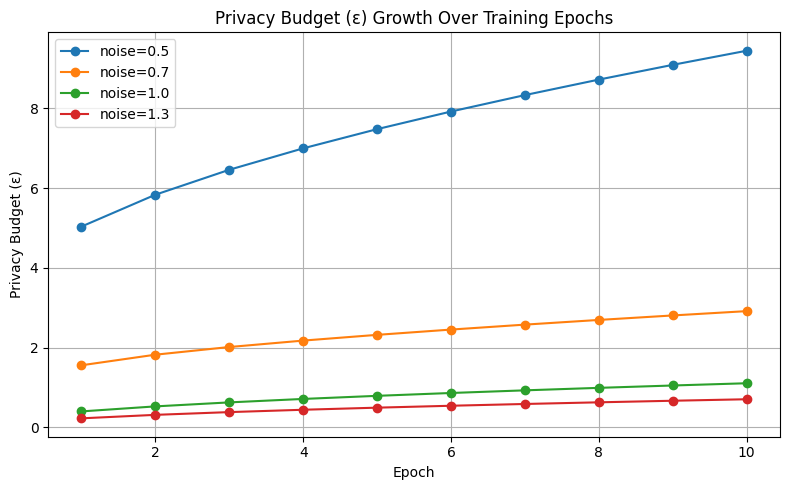

In [21]:
plt.figure(figsize=(8, 5))
for nm, data in tracked_results.items():
    plt.plot(range(1, 11), data["epsilons"], marker='o', label=f'noise={nm}')

plt.xlabel('Epoch')
plt.ylabel('Privacy Budget (ε)')
plt.title('Privacy Budget (ε) Growth Over Training Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DP_Midterm/epsilon_vs_epoch.png')
plt.show()

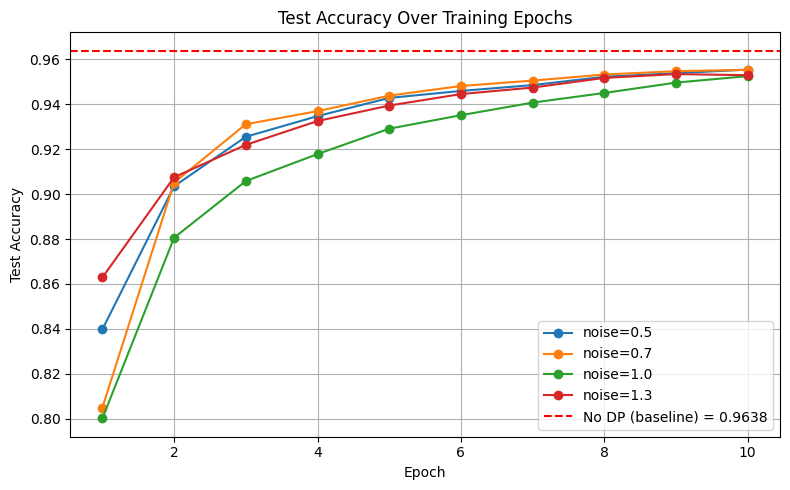

In [22]:
plt.figure(figsize=(8, 5))
for nm, data in tracked_results.items():
    plt.plot(range(1, 11), data["accuracies"], marker='o', label=f'noise={nm}')

# Add baseline
plt.axhline(y=baseline_acc, color='red', linestyle='--', label=f'No DP (baseline) = {baseline_acc:.4f}')

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Over Training Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DP_Midterm/accuracy_vs_epoch.png')
plt.show()

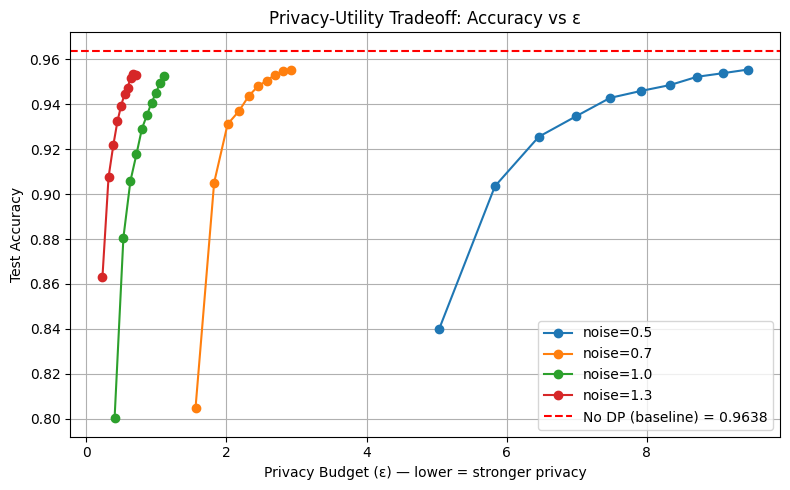

In [23]:
plt.figure(figsize=(8, 5))
for nm, data in tracked_results.items():
    plt.plot(data["epsilons"], data["accuracies"], marker='o', label=f'noise={nm}')

plt.axhline(y=baseline_acc, color='red', linestyle='--', label=f'No DP (baseline) = {baseline_acc:.4f}')

plt.xlabel('Privacy Budget (ε) — lower = stronger privacy')
plt.ylabel('Test Accuracy')
plt.title('Privacy-Utility Tradeoff: Accuracy vs ε')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DP_Midterm/accuracy_vs_epsilon.png')
plt.show()